In [13]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\Sales Transaction.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Dataset Shape: (536350, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12-09-2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12-09-2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12-09-2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12-09-2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12-09-2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [15]:
df.info()

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB

Columns:
['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country']

Dataset Shape:
(536350, 8)


In [16]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_values

,Missing_Count,Missing_Percentage
TransactionNo,0,0.00
Date,0,0.00
ProductNo,0,0.00
ProductName,0,0.00
Price,0,0.00
Quantity,0,0.00
CustomerNo,55,0.01
Country,0,0.00


In [17]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 5200


In [18]:
df_clean = df.drop_duplicates().copy()

print("Original Dataset Rows:", len(df))
print("Duplicate Records Removed:", len(df) - len(df_clean))
print("Cleaned Dataset Rows:", len(df_clean))

print("\nRemaining Duplicate Records:", df_clean.duplicated().sum())

Original Dataset Rows: 536350
Duplicate Records Removed: 5200
Cleaned Dataset Rows: 531150

Remaining Duplicate Records: 0


In [19]:
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    format="mixed",
    errors="coerce"
)

df_clean["CustomerNo"] = df_clean["CustomerNo"].astype("Int64")

print("Invalid Dates:", df_clean["Date"].isna().sum())

df_clean.info()

Invalid Dates: 0
<class 'pandas.core.frame.DataFrame'>
Index: 531150 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  531150 non-null  object        
 1   Date           531150 non-null  datetime64[ns]
 2   ProductNo      531150 non-null  object        
 3   ProductName    531150 non-null  object        
 4   Price          531150 non-null  float64       
 5   Quantity       531150 non-null  int64         
 6   CustomerNo     531095 non-null  Int64         
 7   Country        531150 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 37.0+ MB


In [20]:
print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Records:")
print(df_clean.duplicated().sum())

print("\nInvalid Dates:")
print(df_clean["Date"].isna().sum())

Original Dataset Shape: (536350, 8)
Cleaned Dataset Shape: (531150, 8)

Missing Values:
TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

Duplicate Records:
0

Invalid Dates:
0


In [21]:
customer_df = df_clean.dropna(
    subset=["CustomerNo"]
).copy()

print("Cleaned Dataset Rows:", len(df_clean))
print("Customer Analysis Rows:", len(customer_df))

print(
    "Rows Excluded Due to Missing CustomerNo:",
    len(df_clean) - len(customer_df)
)

Cleaned Dataset Rows: 531150
Customer Analysis Rows: 531095
Rows Excluded Due to Missing CustomerNo: 55


In [22]:
df_clean["Is_Returned"] = (
    df_clean["TransactionNo"]
    .astype(str)
    .str.startswith("C")
    .astype(int)
)

print(df_clean["Is_Returned"].value_counts())

Is_Returned
0    522602
1      8548
Name: count, dtype: int64


In [23]:
return_percentage = df_clean["Is_Returned"].mean() * 100

print("Overall Return Rate:", round(return_percentage, 2), "%")

Overall Return Rate: 1.61 %


In [24]:
df_clean["Transaction_Value"] = (
    df_clean["Price"] * df_clean["Quantity"]
)

df_clean[
    [
        "TransactionNo",
        "Price",
        "Quantity",
        "Transaction_Value",
        "Is_Returned"
    ]
].head(10)

,TransactionNo,Price,Quantity,Transaction_Value,Is_Returned
0,581482,21.47,12,257.64,0
1,581475,10.65,36,383.40,0
2,581475,11.53,12,138.36,0
3,581475,10.65,12,127.80,0
4,581475,11.94,6,71.64,0
5,581475,10.65,24,255.60,0
6,581475,11.53,18,207.54,0
7,581475,12.25,12,147.00,0
8,581475,10.65,12,127.80,0
9,581475,10.55,24,253.20,0


In [25]:
df_clean["Transaction_Value"].describe()

count    5.311500e+05
mean     1.131823e+02
std      2.288288e+03
min     -8.401138e+05
25%      1.618000e+01
50%      4.344000e+01
75%      1.194000e+02
max      1.002718e+06
Name: Transaction_Value, dtype: float64

In [26]:
sales_df = df_clean[
    (df_clean["Is_Returned"] == 0)
    & (df_clean["Date"].notna())
].copy()

print("Cleaned Dataset Rows:", len(df_clean))
print("Completed Sales Rows:", len(sales_df))
print("Excluded Return/Invalid Date Rows:", len(df_clean) - len(sales_df))

Cleaned Dataset Rows: 531150
Completed Sales Rows: 522602
Excluded Return/Invalid Date Rows: 8548


In [27]:
print(
    "Negative Quantity Rows in Completed Sales:",
    (sales_df["Quantity"] < 0).sum()
)

Negative Quantity Rows in Completed Sales: 0


In [28]:
sales_df["Month"] = (
    sales_df["Date"]
    .dt.to_period("M")
    .astype(str)
)

In [29]:
monthly_sales = (
    sales_df
    .groupby("Month", as_index=False)["Transaction_Value"]
    .sum()
)

monthly_sales

,Month,Transaction_Value
0,2018-12,4397648.39
1,2019-01,4548423.47
2,2019-02,3327342.64
3,2019-03,4384669.82
4,2019-04,3579310.06
5,2019-05,4569952.21
6,2019-06,4486132.15
7,2019-07,4571494.88
8,2019-08,4749801.23
9,2019-09,6613772.79


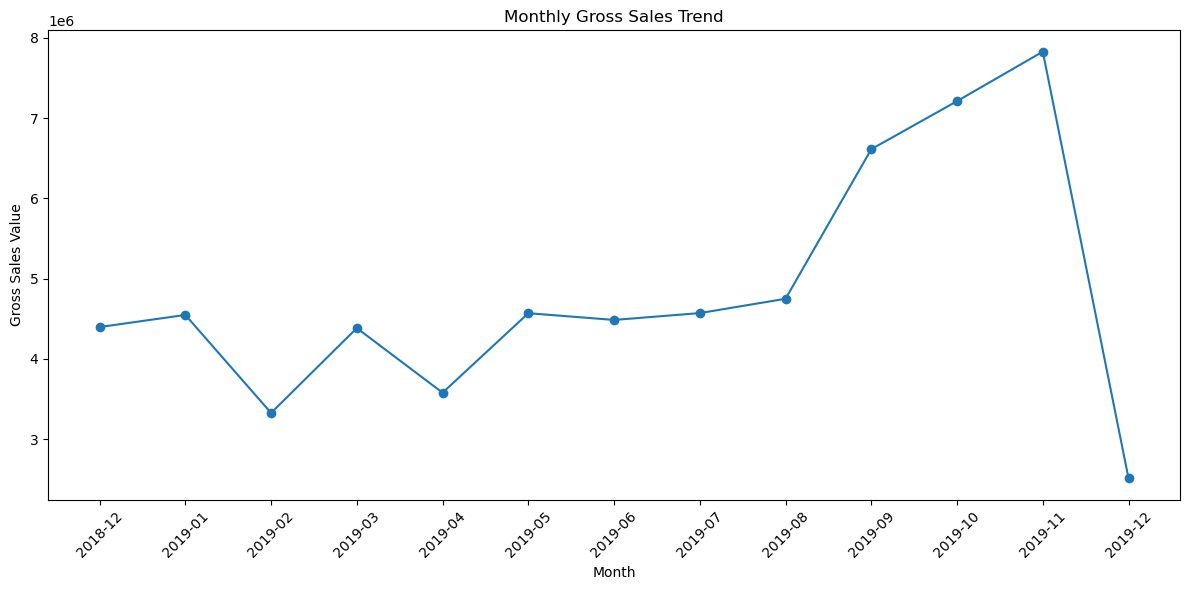

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Transaction_Value"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Gross Sales Value")
plt.title("Monthly Gross Sales Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
top_products = (
    sales_df
    .groupby("ProductName", as_index=False)["Transaction_Value"]
    .sum()
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .head(10)
)

top_products

,ProductName,Transaction_Value
2203,Paper Craft Little Birdie,1002718.10
1887,Medium Ceramic Top Storage Jar,881990.18
2481,Popcorn Holder,587222.66
3670,World War 2 Gliders Asstd Designs,568722.59
825,Cream Hanging Heart T-Light Holder,484354.72
203,Assorted Colour Bird Ornament,420132.72
2157,Pack Of 72 Retrospot Cake Cases,391241.08
2540,Rabbit Night Light,328529.51
2652,Regency Cakestand 3 Tier,306900.94
1672,Jumbo Bag Red Retrospot,296584.47


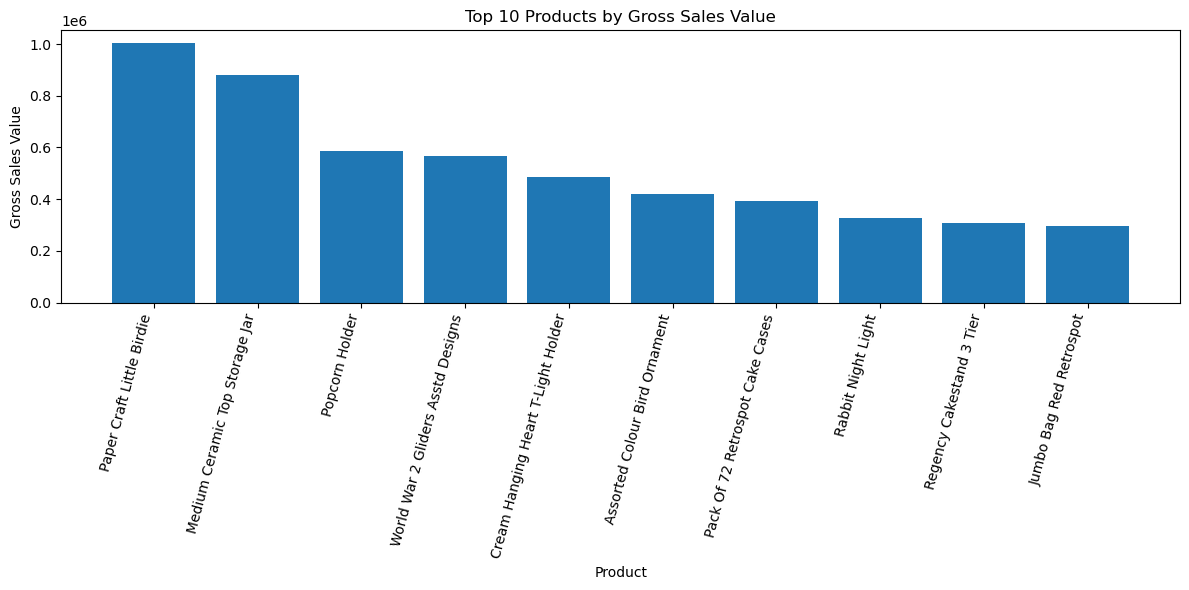

In [32]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_products["ProductName"],
    top_products["Transaction_Value"]
)

plt.xlabel("Product")
plt.ylabel("Gross Sales Value")
plt.title("Top 10 Products by Gross Sales Value")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

In [33]:
country_sales = (
    sales_df
    .groupby("Country", as_index=False)["Transaction_Value"]
    .sum()
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .head(10)
)

country_sales

,Country,Transaction_Value
36,United Kingdom,52346877.60
24,Netherlands,2151553.59
10,EIRE,1711819.39
14,Germany,1369839.62
13,France,1329903.39
0,Australia,995414.01
32,Sweden,401879.89
33,Switzerland,361691.96
20,Japan,293155.44
31,Spain,280843.80


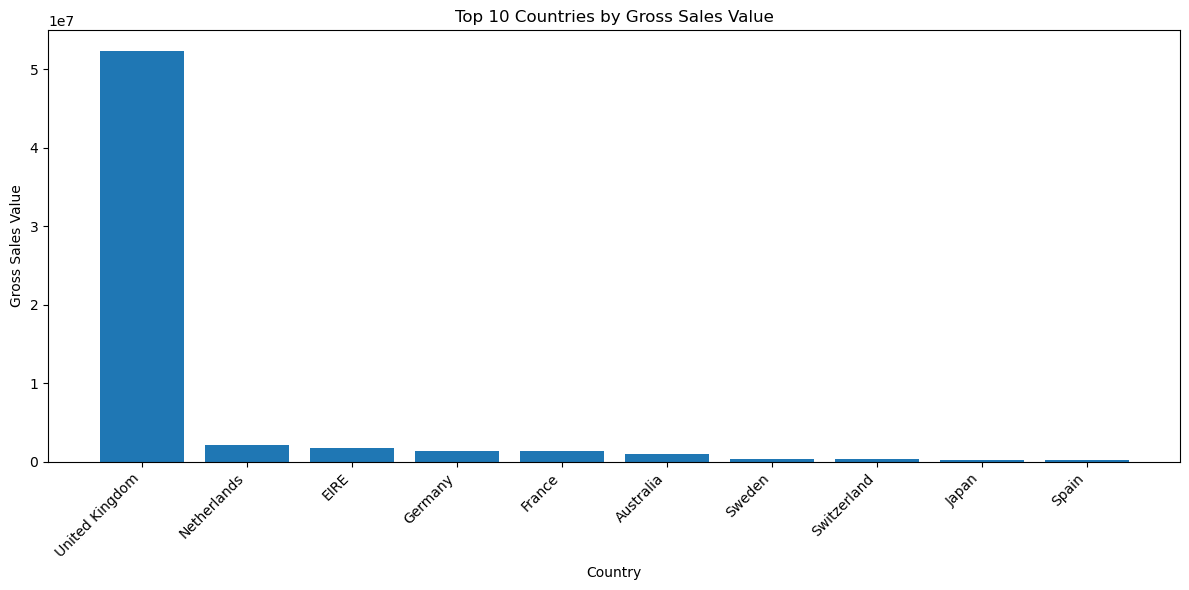

In [34]:
plt.figure(figsize=(12, 6))

plt.bar(
    country_sales["Country"],
    country_sales["Transaction_Value"]
)

plt.xlabel("Country")
plt.ylabel("Gross Sales Value")
plt.title("Top 10 Countries by Gross Sales Value")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [35]:
return_summary = (
    df_clean
    .groupby("Is_Returned")
    .size()
    .reset_index(name="Transaction_Count")
)

return_summary["Transaction_Type"] = (
    return_summary["Is_Returned"]
    .map({
        0: "Sales",
        1: "Returns"
    })
)

return_summary

,Is_Returned,Transaction_Count,Transaction_Type
0,0,522602,Sales
1,1,8548,Returns


In [36]:
overall_return_rate = (
    df_clean["Is_Returned"].mean() * 100
)

print(
    "Overall Return Rate:",
    round(overall_return_rate, 2),
    "%"
)

Overall Return Rate: 1.61 %


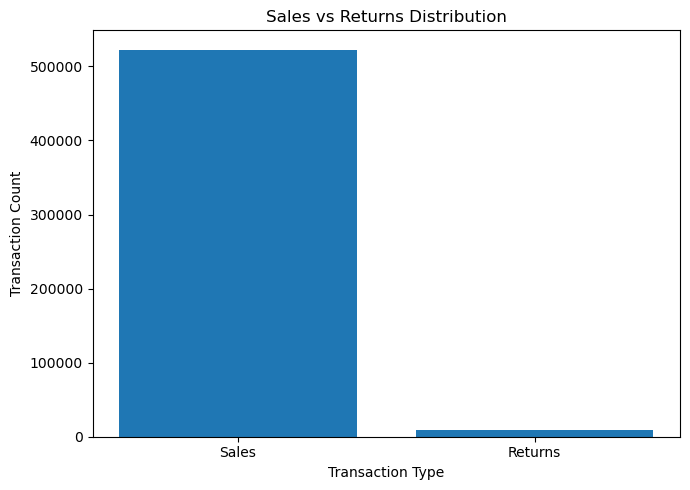

In [37]:
plt.figure(figsize=(7, 5))

plt.bar(
    return_summary["Transaction_Type"],
    return_summary["Transaction_Count"]
)

plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")
plt.title("Sales vs Returns Distribution")

plt.tight_layout()
plt.show()

In [38]:
returned_df = df_clean[
    df_clean["Is_Returned"] == 1
].copy()

top_returned_products = (
    returned_df
    .groupby("ProductName")
    .size()
    .reset_index(name="Returned_Transactions")
    .sort_values(
        "Returned_Transactions",
        ascending=False
    )
    .head(10)
)

top_returned_products

,ProductName,Returned_Transactions
1356,Regency Cakestand 3 Tier,180
862,Jam Making Set With Jars,87
1486,Set Of 3 Cake Tins Pantry Design,73
1657,Strawberry Ceramic Trinket Pot,60
1411,Roses Regency Teacup And Saucer,54
1258,Popcorn Holder,50
1282,Recipe Box Pantry Yellow Design,47
882,Jumbo Bag Red Retrospot,44
415,Cream Hanging Heart T-Light Holder,42
1320,Red Retrospot Cake Stand,42


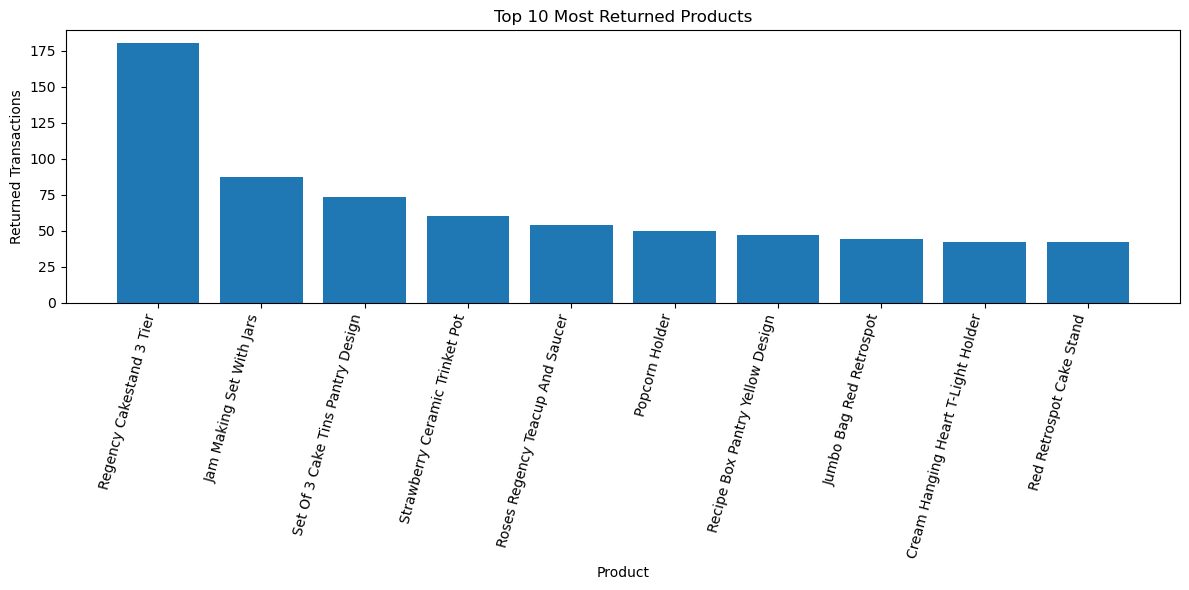

In [39]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_returned_products["ProductName"],
    top_returned_products["Returned_Transactions"]
)

plt.xlabel("Product")
plt.ylabel("Returned Transactions")
plt.title("Top 10 Most Returned Products")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

In [40]:
output_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\cleaned_sales_transaction.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print("Saved Rows:", len(df_clean))
print("Saved Columns:", len(df_clean.columns))

Cleaned dataset saved successfully.
Saved Rows: 531150
Saved Columns: 10


In [41]:
import os

print("File Exists:", os.path.exists(output_path))
print("File Location:", output_path)

File Exists: True
File Location: C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\cleaned_sales_transaction.csv


In [43]:
import os

output_folder = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data"

os.makedirs(output_folder, exist_ok=True)

monthly_sales.to_csv(
    os.path.join(output_folder, "monthly_sales.csv"),
    index=False
)

top_products.to_csv(
    os.path.join(output_folder, "top_products.csv"),
    index=False
)

country_sales.to_csv(
    os.path.join(output_folder, "country_sales.csv"),
    index=False
)

return_summary.to_csv(
    os.path.join(output_folder, "return_summary.csv"),
    index=False
)

top_returned_products.to_csv(
    os.path.join(output_folder, "top_returned_products.csv"),
    index=False
)

print("All analysis results saved successfully.")

All analysis results saved successfully.


In [46]:
output_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\cleaned_sales_transaction_v2.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [47]:
test_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\test.csv"

pd.DataFrame({
    "A": [1, 2, 3]
}).to_csv(test_path, index=False)

print("Test file saved successfully.")

Test file saved successfully.


In [48]:
df_clean.to_csv(output_path, index=False)

In [49]:
customer_df = df_clean.dropna(subset=["CustomerNo"]).copy()

In [50]:
customer_output_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\customer_sales_transaction.csv"

customer_df.to_csv(
    customer_output_path,
    index=False
)

print("Customer-level dataset saved successfully.")
print("Rows:", len(customer_df))

Customer-level dataset saved successfully.
Rows: 531095


In [51]:
df_clean.isnull().sum()

TransactionNo         0
Date                  0
ProductNo             0
ProductName           0
Price                 0
Quantity              0
CustomerNo           55
Country               0
Is_Returned           0
Transaction_Value     0
dtype: int64

In [52]:
customer_df = df_clean.dropna(
    subset=["CustomerNo"]
).copy()

print("df_clean Rows:", len(df_clean))
print("customer_df Rows:", len(customer_df))
print("Null CustomerNo in customer_df:",
      customer_df["CustomerNo"].isnull().sum())

df_clean Rows: 531150
customer_df Rows: 531095
Null CustomerNo in customer_df: 0


In [53]:
df_clean.isnull().sum()

TransactionNo         0
Date                  0
ProductNo             0
ProductName           0
Price                 0
Quantity              0
CustomerNo           55
Country               0
Is_Returned           0
Transaction_Value     0
dtype: int64

In [54]:
df_clean = df_clean.dropna(subset=["CustomerNo"]).copy()

print(df_clean.isnull().sum())
print("Total Null Values:", df_clean.isnull().sum().sum())
print("Final Dataset Rows:", len(df_clean))

TransactionNo        0
Date                 0
ProductNo            0
ProductName          0
Price                0
Quantity             0
CustomerNo           0
Country              0
Is_Returned          0
Transaction_Value    0
dtype: int64
Total Null Values: 0
Final Dataset Rows: 531095


In [57]:
output_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\cleaned_sales_transaction.csv"

df_clean.to_csv(output_path, index=False)

print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.
